<a href="https://colab.research.google.com/github/Carozuhe/Simulacion/blob/main/Simulacion_Mercado_Financiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

╔══════════════════════════════════════════════════════════════╗
║  🏦  HMM — REGÍMENES DE MERCADO FINANCIERO                  ║
║  500 simulaciones × 50 períodos = 25,000 observaciones totales       ║
╚══════════════════════════════════════════════════════════════╝

  📐  Distribución estacionaria teórica (π*):
      Mercado Alcista: 0.3333
      Mercado Lateral: 0.3333
      Mercado Bajista: 0.3333

────────────────────────────────────────────────────────────
  🚀  Ejecutando 500 simulaciones de 50 períodos…
────────────────────────────────────────────────────────────
  [██░░░░░░░░░░░░░░░░░░]   10.0%  —  sim    50/500
  [████░░░░░░░░░░░░░░░░]   20.0%  —  sim   100/500
  [██████░░░░░░░░░░░░░░]   30.0%  —  sim   150/500
  [████████░░░░░░░░░░░░]   40.0%  —  sim   200/500
  [██████████░░░░░░░░░░]   50.0%  —  sim   250/500
  [████████████░░░░░░░░]   60.0%  —  sim   300/500
  [██████████████░░░░░░]   70.0%  —  sim   350/500
  [████████████████░░░░]   80.0%  —  sim   400/500
  [███████████████

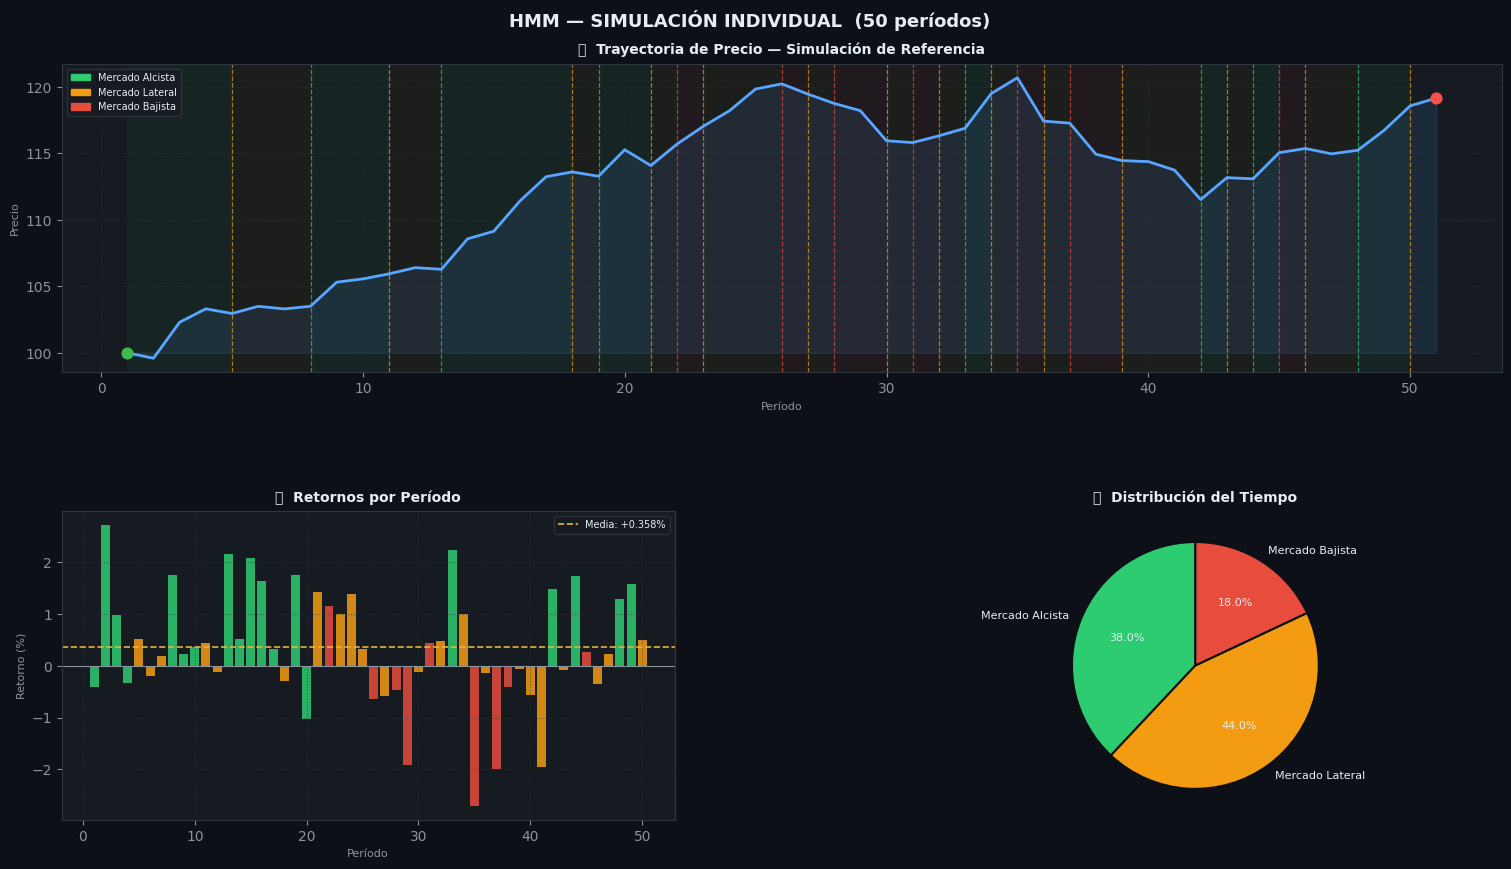

  💾  Guardado: fig2_convergencia.png


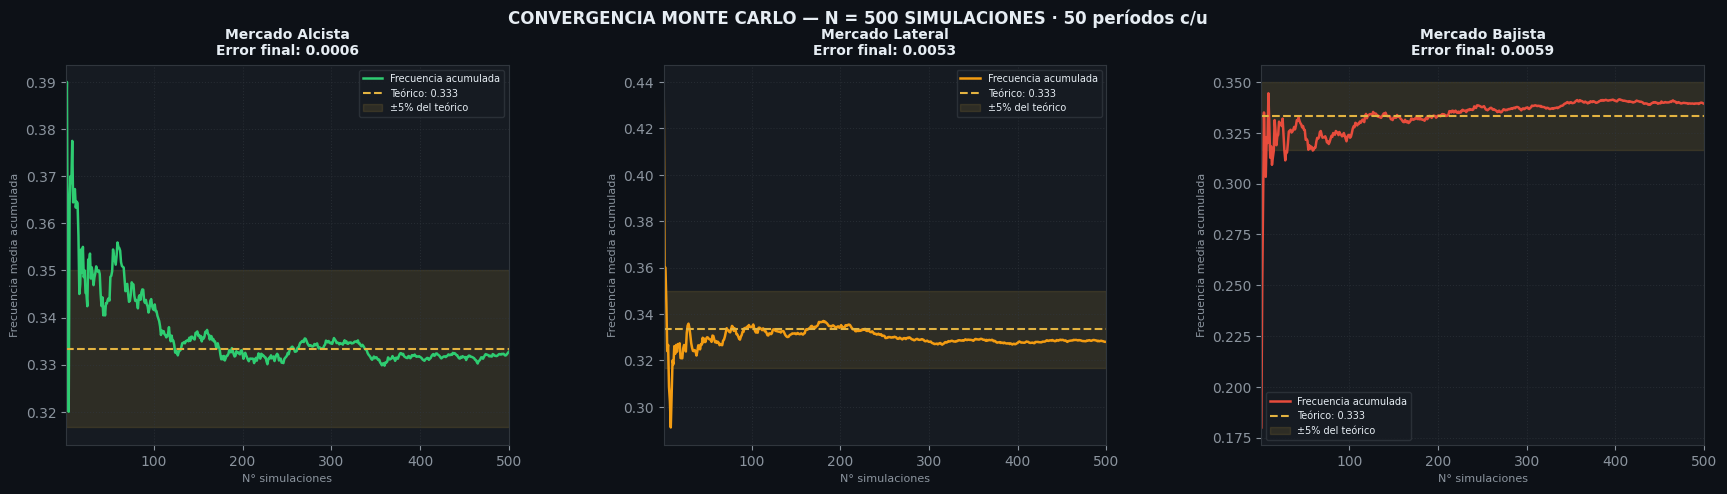

  💾  Guardado: fig3_distribuciones.png


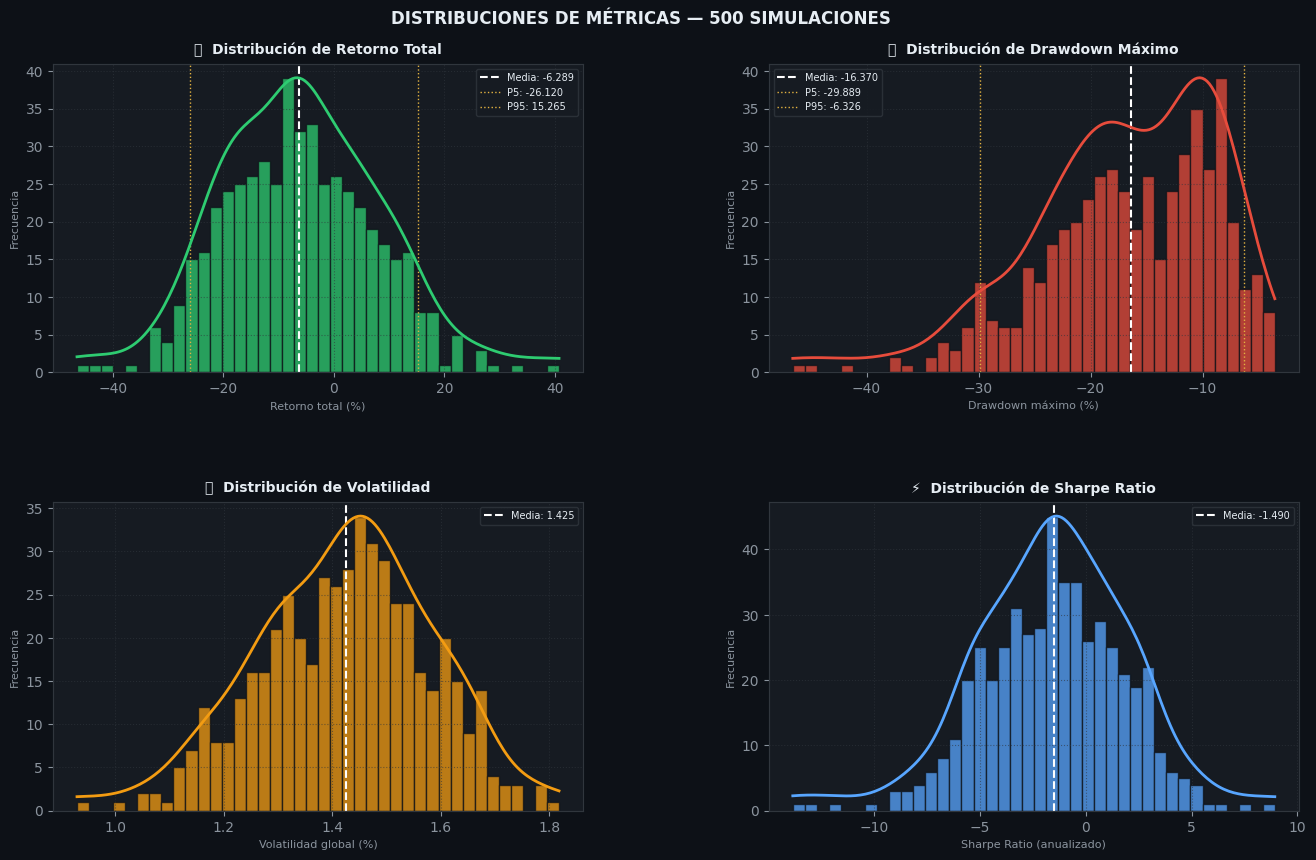

  💾  Guardado: fig4_fan_chart.png


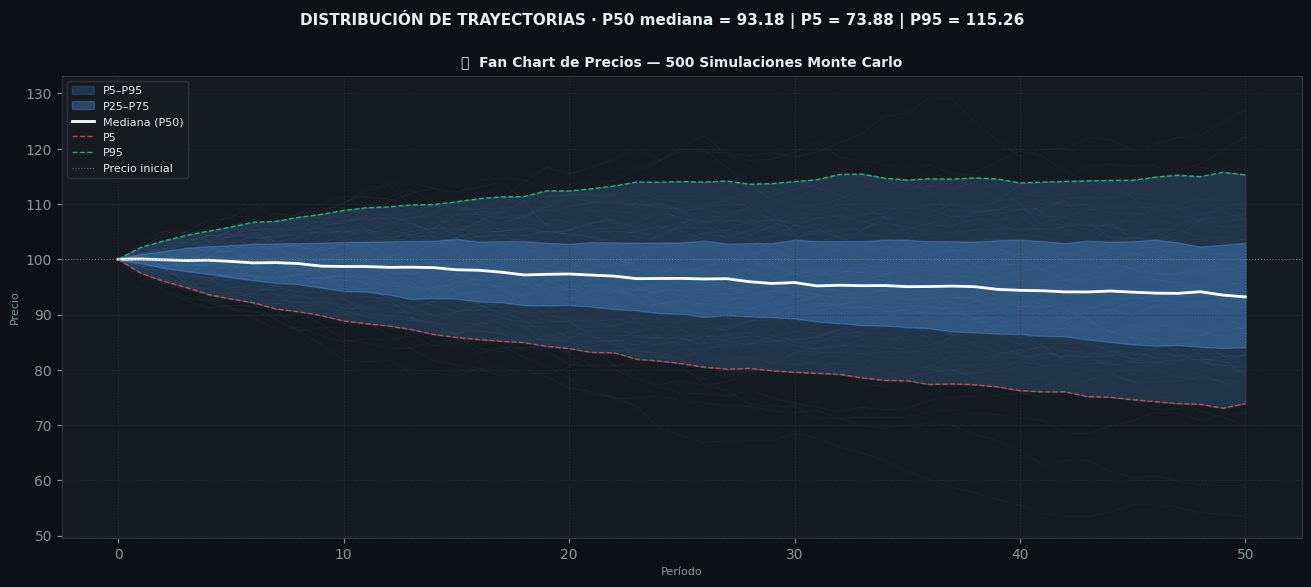

  💾  Guardado: fig5_regimenes.png


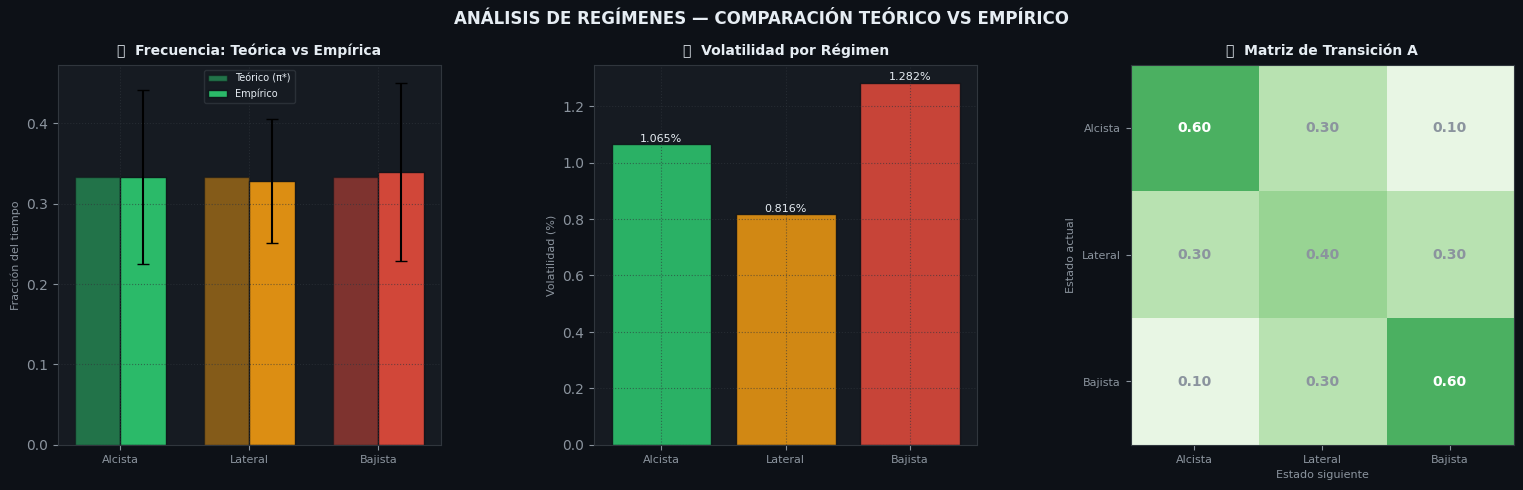

✅  Ejecución completa. Revisa las imágenes guardadas.



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from collections import defaultdict
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURACIÓN GLOBAL — modifica estos valores para personalizar
# ─────────────────────────────────────────────────────────────────────────────
CONFIG = {
    "N_SIMULACIONES":  500,    # número de simulaciones Monte Carlo
    "N_PERIODOS":       50,    # períodos por simulación
    "PRECIO_INICIAL": 100.0,   # precio de inicio de cada simulación
    "SEMILLA":         42,     # semilla global para reproducibilidad
    "GUARDAR_GRAFICOS": True,  # guarda .png además de mostrar
    "VERBOSE_SIM":      False, # True → imprime tabla de cada simulación
}

np.random.seed(CONFIG["SEMILLA"])


# ══════════════════════════════════════════════════════════════════════════════
#  CLASE 1: HMM PARA MERCADOS FINANCIEROS
# ══════════════════════════════════════════════════════════════════════════════
class HMM_Mercado:
    """
    Modelo Oculto de Markov para regímenes de mercado financiero.

    Componentes
    ───────────rcado Alcista | Mercado Lateral |
    Estados ocultos  : Me Mercado Bajista
    Observaciones    : Retorno Positivo | Retorno Neutral | Retorno Negativo
    π  (inicial)     : probabilidad de comenzar en cada estado
    A  (transición)  : P(estado_t+1 | estado_t)
    B  (emisión)     : P(observación | estado)
    """

    # ── Paletas ───────────────────────────────────────────────────────────────
    COLORES = {
        "Mercado Alcista": "#2ecc71",
        "Mercado Lateral": "#f39c12",
        "Mercado Bajista": "#e74c3c",
    }
    FONDO = {
        "Mercado Alcista": "#1a3a2a",
        "Mercado Lateral": "#2a2510",
        "Mercado Bajista": "#3a1a1a",
    }

    def __init__(self):
        self.estados        = ["Mercado Alcista", "Mercado Lateral", "Mercado Bajista"]
        self.observaciones  = ["Retorno Positivo", "Retorno Neutral",  "Retorno Negativo"]
        self.n_estados      = 3
        self.n_obs          = 3

        # ── Distribución inicial π ────────────────────────────────────────────
        self.pi = np.array([0.4, 0.3, 0.3])

        # ── Matriz de transición A ────────────────────────────────────────────
        self.A = np.array([
            [0.6, 0.3, 0.1],   # desde Alcista
            [0.3, 0.4, 0.3],   # desde Lateral
            [0.1, 0.3, 0.6],   # desde Bajista
        ])

        # ── Matriz de emisión B ───────────────────────────────────────────────
        self.B = np.array([
            [0.7, 0.2, 0.1],   # Alcista
            [0.3, 0.4, 0.3],   # Lateral
            [0.1, 0.2, 0.7],   # Bajista
        ])

        # ── Distribución estacionaria teórica ─────────────────────────────────
        # Resuelta: π* A = π*  →  para esta A simétrica = [1/3, 1/3, 1/3]
        self.pi_estacionaria = self._calcular_estacionaria()

        # ── Parámetros de retorno (μ, σ) por (estado, observación) ────────────
        self.ret_params = {
            ("Mercado Alcista", "Retorno Positivo"): ( 0.015, 0.008),
            ("Mercado Alcista", "Retorno Neutral"):  ( 0.002, 0.005),
            ("Mercado Alcista", "Retorno Negativo"): (-0.008, 0.006),
            ("Mercado Lateral", "Retorno Positivo"): ( 0.008, 0.006),
            ("Mercado Lateral", "Retorno Neutral"):  ( 0.000, 0.004),
            ("Mercado Lateral", "Retorno Negativo"): (-0.008, 0.006),
            ("Mercado Bajista", "Retorno Positivo"): ( 0.005, 0.007),
            ("Mercado Bajista", "Retorno Neutral"):  (-0.003, 0.005),
            ("Mercado Bajista", "Retorno Negativo"): (-0.020, 0.010),
        }

        self._validar()

    # ── Distribución estacionaria vía álgebra lineal ───────────────────────────
    def _calcular_estacionaria(self):
        """Resuelve π* = π* A con suma = 1 usando eigenvalores."""
        eigenvals, eigenvecs = np.linalg.eig(self.A.T)
        idx = np.argmin(np.abs(eigenvals - 1.0))
        pi_stat = eigenvecs[:, idx].real
        return np.abs(pi_stat) / np.abs(pi_stat).sum()

    def _validar(self):
        assert np.isclose(self.pi.sum(), 1.0),        "π no suma 1"
        assert np.allclose(self.A.sum(axis=1), 1.0),  "Filas de A no suman 1"
        assert np.allclose(self.B.sum(axis=1), 1.0),  "Filas de B no suman 1"

    # ── Muestreo ───────────────────────────────────────────────────────────────
    def _sig_estado(self, idx):
        return np.random.choice(self.n_estados, p=self.A[idx])

    def _observacion(self, idx):
        return np.random.choice(self.n_obs, p=self.B[idx])

    def _retorno(self, estado, obs):
        mu, sigma = self.ret_params[(estado, obs)]
        return np.random.normal(mu, sigma)

    # ── Simulación de una trayectoria ─────────────────────────────────────────
    def simular_una(self, n_periodos, precio_inicial=100.0, verbose=False):
        """Simula una trayectoria de n_periodos y devuelve dict con resultados."""
        estado_idx = np.random.choice(self.n_estados, p=self.pi)
        precio     = precio_inicial

        precios, estados, observaciones, retornos = [precio_inicial], [], [], []

        if verbose:
            print(f"{'T':>4}  {'Estado':<20}  {'Obs':<20}  {'Ret':>8}  {'Precio':>9}")
            print("─" * 68)

        for t in range(n_periodos):
            estado  = self.estados[estado_idx]
            obs_idx = self._observacion(estado_idx)
            obs     = self.observaciones[obs_idx]
            ret     = self._retorno(estado, obs)
            precio *= (1 + ret)

            estados.append(estado)
            observaciones.append(obs)
            retornos.append(ret)
            precios.append(precio)

            if verbose:
                ico = "🟢" if "Alcista" in estado else ("🟡" if "Lateral" in estado else "🔴")
                print(f"{t+1:>4}  {ico}{estado:<19}  {obs:<20}  {ret:>+.4f}  {precio:>9.4f}")

            estado_idx = self._sig_estado(estado_idx)

        retornos_np = np.array(retornos)
        precios_np  = np.array(precios)

        # Drawdown máximo
        pico     = np.maximum.accumulate(precios_np)
        drawdown = ((precios_np - pico) / pico).min() * 100

        # Frecuencias de régimen
        freq = {e: estados.count(e) / n_periodos for e in self.estados}

        # Volatilidad y retorno por régimen
        ret_por_reg = {}
        for e in self.estados:
            idx_e = [i for i, s in enumerate(estados) if s == e]
            ret_por_reg[e] = retornos_np[idx_e] if idx_e else np.array([0.0])

        return {
            "precios":        precios_np,
            "estados":        estados,
            "observaciones":  observaciones,
            "retornos":       retornos_np,
            "retorno_total":  (precios_np[-1] / precios_np[0] - 1) * 100,
            "max_drawdown":   drawdown,
            "volatilidad":    retornos_np.std() * 100,
            "sharpe":         (retornos_np.mean() / retornos_np.std() * np.sqrt(252)
                               if retornos_np.std() > 0 else 0),
            "frecuencias":    freq,
            "ret_por_reg":    ret_por_reg,
            "precio_final":   precios_np[-1],
        }

    # ── Algoritmo de Viterbi ───────────────────────────────────────────────────
    def viterbi(self, secuencia_obs):
        """
        Decodifica la secuencia más probable de estados ocultos
        para una secuencia de observaciones dada.

        Parámetros
        ──────────
        secuencia_obs : list[str]  — nombres de observaciones
        Retorna       : list[str]  — secuencia de estados más probable
        """
        obs_idx = [self.observaciones.index(o) for o in secuencia_obs]
        T       = len(obs_idx)

        delta = np.zeros((T, self.n_estados))
        psi   = np.zeros((T, self.n_estados), dtype=int)

        # Inicialización
        delta[0] = self.pi * self.B[:, obs_idx[0]]

        # Recursión
        for t in range(1, T):
            for j in range(self.n_estados):
                trans = delta[t-1] * self.A[:, j]
                psi[t, j]   = np.argmax(trans)
                delta[t, j] = trans[psi[t, j]] * self.B[j, obs_idx[t]]

        # Backtracking
        ruta = np.zeros(T, dtype=int)
        ruta[-1] = np.argmax(delta[-1])
        for t in range(T - 2, -1, -1):
            ruta[t] = psi[t + 1, ruta[t + 1]]

        return [self.estados[i] for i in ruta]

    # ── Recomendaciones de trading ─────────────────────────────────────────────
    def recomendaciones(self, estado_actual, estado_anterior=None):
        tabla = {
            "Mercado Alcista": {
                "accion": "COMPRAR / MANTENER LARGO",
                "riesgo": "BAJO–MEDIO",
                "stop":   "3–5 % bajo entrada",
                "take":   "8–15 %",
                "apalan": "1× – 2×",
                "desc":   "Tendencia alcista confirmada. Favorecer largos, ampliar stops dinámicos.",
            },
            "Mercado Lateral": {
                "accion": "RANGE TRADING / NEUTRAL",
                "riesgo": "MEDIO",
                "stop":   "2–3 % fuera del rango",
                "take":   "3–5 %",
                "apalan": "1×",
                "desc":   "Sin tendencia. Vender resistencia, comprar soporte; evitar falsos breakouts.",
            },
            "Mercado Bajista": {
                "accion": "REDUCIR / CORTO / COBERTURA",
                "riesgo": "ALTO",
                "stop":   "2 % sobre entrada en cortos",
                "take":   "10–20 %",
                "apalan": "0.5× o ninguno en largos",
                "desc":   "Mercado en caída. Preservar capital, considerar puts o ETFs inversos.",
            },
        }
        rec = tabla[estado_actual].copy()
        rec["estado"]   = estado_actual
        rec["prob_perm"] = self.A[
            self.estados.index(estado_actual),
            self.estados.index(estado_actual),
        ] * 100
        if estado_anterior and estado_anterior != estado_actual:
            rec["alerta"] = f"⚠️  CAMBIO DE RÉGIMEN: {estado_anterior} → {estado_actual}"
        else:
            rec["alerta"] = f"✅  Régimen estable (prob. continuidad: {rec['prob_perm']:.0f}%)"
        return rec


# ══════════════════════════════════════════════════════════════════════════════
#  CLASE 2: MOTOR DE SIMULACIONES MONTE CARLO
# ══════════════════════════════════════════════════════════════════════════════
class MonteCarloHMM:
    """
    Ejecuta N simulaciones independientes y analiza la convergencia
    de las frecuencias de régimen y métricas financieras.
    """

    def __init__(self, hmm: HMM_Mercado, n_sim: int, n_periodos: int,
                 precio_inicial: float = 100.0):
        self.hmm            = hmm
        self.n_sim          = n_sim
        self.n_periodos     = n_periodos
        self.precio_inicial = precio_inicial
        self.resultados     = []          # lista de dicts de cada simulación

    # ── Ejecutar todas las simulaciones ───────────────────────────────────────
    def ejecutar(self, verbose=False):
        print(f"{'─'*60}")
        print(f"  🚀  Ejecutando {self.n_sim} simulaciones de {self.n_periodos} períodos…")
        print(f"{'─'*60}")

        for i in range(self.n_sim):
            res = self.hmm.simular_una(self.n_periodos, self.precio_inicial,
                                       verbose=verbose)
            self.resultados.append(res)
            if (i + 1) % max(1, self.n_sim // 10) == 0:
                pct = (i + 1) / self.n_sim * 100
                bar = "█" * int(pct // 5) + "░" * (20 - int(pct // 5))
                print(f"  [{bar}]  {pct:5.1f}%  —  sim {i+1:>5}/{self.n_sim}")

        print(f"{'─'*60}")
        print(f"  ✅  {self.n_sim} simulaciones completadas.\n")
        return self

    # ── Convergencia acumulada de frecuencias ──────────────────────────────────
    def convergencia_frecuencias(self):
        """
        Para cada n en 1…N, calcula la frecuencia media acumulada de cada
        régimen. Muestra cómo se acerca al valor estacionario teórico.
        """
        frecuencias_acum = {e: [] for e in self.hmm.estados}
        acum = {e: 0.0 for e in self.hmm.estados}

        for i, res in enumerate(self.resultados, 1):
            for e in self.hmm.estados:
                acum[e] += res["frecuencias"][e]
                frecuencias_acum[e].append(acum[e] / i)

        return frecuencias_acum   # dict → list de promedios acumulados

    # ── Estadísticas agregadas ────────────────────────────────────────────────
    def estadisticas(self):
        rts  = np.array([r["retorno_total"]  for r in self.resultados])
        dds  = np.array([r["max_drawdown"]   for r in self.resultados])
        vols = np.array([r["volatilidad"]    for r in self.resultados])
        shs  = np.array([r["sharpe"]         for r in self.resultados])
        pfs  = np.array([r["precio_final"]   for r in self.resultados])

        freq_medias = {}
        freq_stds   = {}
        for e in self.hmm.estados:
            vals = np.array([r["frecuencias"][e] for r in self.resultados])
            freq_medias[e] = vals.mean()
            freq_stds[e]   = vals.std()

        vol_reg = {}
        for e in self.hmm.estados:
            todos = np.concatenate([r["ret_por_reg"][e] for r in self.resultados])
            vol_reg[e] = todos.std() * 100 if len(todos) > 1 else 0.0

        return {
            "retorno":      {"media": rts.mean(),  "std": rts.std(),
                             "p5": np.percentile(rts, 5),
                             "p95": np.percentile(rts, 95),
                             "datos": rts},
            "drawdown":     {"media": dds.mean(),  "std": dds.std(),
                             "p5": np.percentile(dds, 5),
                             "p95": np.percentile(dds, 95),
                             "datos": dds},
            "volatilidad":  {"media": vols.mean(), "std": vols.std(),
                             "datos": vols},
            "sharpe":       {"media": shs.mean(),  "std": shs.std(),
                             "datos": shs},
            "precio_final": {"media": pfs.mean(),  "std": pfs.std(),
                             "datos": pfs},
            "freq_medias":  freq_medias,
            "freq_stds":    freq_stds,
            "vol_por_reg":  vol_reg,
        }

    # ── VaR y CVaR del portafolio de simulaciones ─────────────────────────────
    def analisis_riesgo(self, est):
        rts = est["retorno"]["datos"]
        return {
            "VaR_95":  np.percentile(rts, 5),
            "VaR_99":  np.percentile(rts, 1),
            "CVaR_95": rts[rts <= np.percentile(rts, 5)].mean(),
            "CVaR_99": rts[rts <= np.percentile(rts, 1)].mean(),
            "asim":    stats.skew(rts),
            "kurt":    stats.kurtosis(rts),
            "prob_positivo": (rts > 0).mean() * 100,
        }


# ══════════════════════════════════════════════════════════════════════════════
#  MÓDULO DE VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════
class Visualizador:
    """Genera todos los gráficos del análisis HMM + Monte Carlo."""

    BG      = "#0d1117"
    AX_BG   = "#161b22"
    BORDE   = "#30363d"
    TEXTO   = "#e6edf3"
    MUTED   = "#8b949e"

    COLORES_REG = {
        "Mercado Alcista": "#2ecc71",
        "Mercado Lateral": "#f39c12",
        "Mercado Bajista": "#e74c3c",
    }

    def __init__(self, hmm: HMM_Mercado, mc: MonteCarloHMM,
                 muestra_idx: int = 0, guardar: bool = True):
        self.hmm        = hmm
        self.mc         = mc
        self.muestra    = mc.resultados[muestra_idx]   # 1ª sim para gráf individuales
        self.est        = mc.estadisticas()
        self.riesgo     = mc.analisis_riesgo(self.est)
        self.conv       = mc.convergencia_frecuencias()
        self.guardar    = guardar

        plt.rcParams.update({
            "figure.facecolor":   self.BG,
            "axes.facecolor":     self.AX_BG,
            "axes.edgecolor":     self.BORDE,
            "axes.labelcolor":    self.MUTED,
            "xtick.color":        self.MUTED,
            "ytick.color":        self.MUTED,
            "text.color":         self.TEXTO,
            "grid.color":         self.BORDE,
            "grid.linestyle":     ":",
            "grid.alpha":         0.6,
            "legend.facecolor":   self.AX_BG,
            "legend.edgecolor":   self.BORDE,
        })

    # ── Helper: estilizar ejes ─────────────────────────────────────────────────
    def _ax(self, ax, titulo, xlabel="", ylabel=""):
        ax.set_title(titulo, color=self.TEXTO, fontsize=10, fontweight="bold", pad=7)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(True)

    # ──────────────────────────────────────────────────────────────────────────
    #  FIGURA 1: Simulación individual (precio + retornos + régimen)
    # ──────────────────────────────────────────────────────────────────────────
    def figura_simulacion_individual(self):
        res     = self.muestra
        precios = res["precios"]
        estados = res["estados"]
        retornos= res["retornos"]
        T       = len(estados)
        xs      = list(range(1, T + 2))

        fig = plt.figure(figsize=(16, 9), facecolor=self.BG)
        gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35,
                                left=0.07, right=0.97, top=0.91, bottom=0.07)

        # ── 1a: Precio con fondos por régimen ──────────────────────────────
        ax1 = fig.add_subplot(gs[0, :])
        self._ax(ax1, "📈  Trayectoria de Precio — Simulación de Referencia",
                 "Período", "Precio")

        # Fondos
        seg_ini = 0
        for t in range(1, T):
            if estados[t] != estados[t-1] or t == T-1:
                fin = t if estados[t] != estados[t-1] else t + 1
                ax1.axvspan(seg_ini + 1, fin + 1, alpha=0.3,
                            color=HMM_Mercado.FONDO[estados[seg_ini]], linewidth=0)
                seg_ini = t

        ax1.plot(xs, precios, color="#58a6ff", linewidth=2, zorder=5)
        ax1.fill_between(xs, precios, precios[0], alpha=0.10, color="#58a6ff")
        ax1.scatter([xs[0]],  [precios[0]],  color="#3fb950", s=60, zorder=7,
                    label=f"Inicio: {precios[0]:.2f}")
        ax1.scatter([xs[-1]], [precios[-1]], color="#f85149", s=60, zorder=7,
                    label=f"Final: {precios[-1]:.2f}")

        # Cambios de régimen
        cambios = [(i+1, estados[i]) for i in range(1, T) if estados[i] != estados[i-1]]
        for per, est in cambios:
            ax1.axvline(per, color=self.COLORES_REG[est], lw=0.9, ls="--", alpha=0.7)

        parches = [mpatches.Patch(color=self.COLORES_REG[e], label=e)
                   for e in self.hmm.estados]
        ax1.legend(handles=parches, fontsize=7, loc="upper left",
                   labelcolor=self.TEXTO)

        # ── 1b: Retornos coloreados ────────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, 0])
        self._ax(ax2, "📊  Retornos por Período", "Período", "Retorno (%)")
        cols = [self.COLORES_REG[e] for e in estados]
        ax2.bar(range(1, T + 1), [r * 100 for r in retornos],
                color=cols, alpha=0.85, width=0.8)
        ax2.axhline(0, color=self.MUTED, lw=0.8)
        media = np.mean(retornos) * 100
        ax2.axhline(media, color="#e3b341", lw=1.2, ls="--",
                    label=f"Media: {media:+.3f}%")
        ax2.legend(fontsize=7, labelcolor=self.TEXTO)

        # ── 1c: Distribución de tiempo por régimen ─────────────────────────
        ax3 = fig.add_subplot(gs[1, 1])
        self._ax(ax3, "🕐  Distribución del Tiempo")
        conteo = {e: estados.count(e) for e in self.hmm.estados}
        ax3.pie(
            [conteo[e] for e in self.hmm.estados],
            labels=self.hmm.estados,
            colors=[self.COLORES_REG[e] for e in self.hmm.estados],
            autopct="%1.1f%%",
            startangle=90,
            textprops={"color": self.TEXTO, "fontsize": 8},
            wedgeprops={"edgecolor": self.BG, "linewidth": 1.5},
        )

        fig.suptitle(
            f"HMM — SIMULACIÓN INDIVIDUAL  ({self.mc.n_periodos} períodos)",
            fontsize=13, fontweight="bold", color=self.TEXTO, y=0.97,
        )
        self._guardar(fig, "fig1_simulacion_individual.png")
        plt.show()

    # ──────────────────────────────────────────────────────────────────────────
    #  FIGURA 2: Convergencia Monte Carlo
    # ──────────────────────────────────────────────────────────────────────────
    def figura_convergencia(self):
        conv = self.conv
        N    = self.mc.n_sim
        xs   = list(range(1, N + 1))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=self.BG)
        fig.subplots_adjust(wspace=0.35, left=0.06, right=0.97,
                            top=0.88, bottom=0.12)

        for ax, estado in zip(axes, self.hmm.estados):
            teoria = self.hmm.pi_estacionaria[self.hmm.estados.index(estado)]
            color  = self.COLORES_REG[estado]

            ax.plot(xs, conv[estado], color=color, linewidth=1.8,
                    label="Frecuencia acumulada")
            ax.axhline(teoria, color="#e3b341", lw=1.5, ls="--",
                       label=f"Teórico: {teoria:.3f}")

            # Banda de ±5% del valor teórico
            ax.axhspan(teoria * 0.95, teoria * 1.05, alpha=0.12,
                       color="#e3b341", label="±5% del teórico")

            # Error actual
            error_final = abs(conv[estado][-1] - teoria)
            self._ax(ax, f"{estado}\nError final: {error_final:.4f}",
                     "N° simulaciones", "Frecuencia media acumulada")
            ax.legend(fontsize=7, labelcolor=self.TEXTO)
            ax.set_xlim(1, N)

        fig.suptitle(
            f"CONVERGENCIA MONTE CARLO — N = {N} SIMULACIONES · "
            f"{self.mc.n_periodos} períodos c/u",
            fontsize=12, fontweight="bold", color=self.TEXTO, y=0.99,
        )
        self._guardar(fig, "fig2_convergencia.png")
        plt.show()

    # ──────────────────────────────────────────────────────────────────────────
    #  FIGURA 3: Distribuciones de métricas financieras
    # ──────────────────────────────────────────────────────────────────────────
    def figura_distribuciones(self):
        est = self.est

        fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=self.BG)
        fig.subplots_adjust(hspace=0.42, wspace=0.35,
                            left=0.08, right=0.97, top=0.91, bottom=0.08)

        pares = [
            (est["retorno"]["datos"],     "#2ecc71", "Retorno total (%)",
             est["retorno"]["media"],     est["retorno"]["p5"], est["retorno"]["p95"]),
            (est["drawdown"]["datos"],    "#e74c3c", "Drawdown máximo (%)",
             est["drawdown"]["media"],    est["drawdown"]["p5"], est["drawdown"]["p95"]),
            (est["volatilidad"]["datos"], "#f39c12", "Volatilidad global (%)",
             est["volatilidad"]["media"], None, None),
            (est["sharpe"]["datos"],      "#58a6ff", "Sharpe Ratio (anualizado)",
             est["sharpe"]["media"],      None, None),
        ]

        titulos = ["📈  Distribución de Retorno Total",
                   "📉  Distribución de Drawdown Máximo",
                   "📊  Distribución de Volatilidad",
                   "⚡  Distribución de Sharpe Ratio"]

        for ax, (datos, col, xlabel, media, p5, p95), titulo in \
                zip(axes.flat, pares, titulos):
            ax.hist(datos, bins=40, color=col, alpha=0.75, edgecolor=self.BG)
            ax.axvline(media, color="white", lw=1.5, ls="--",
                       label=f"Media: {media:.3f}")
            if p5 is not None:
                ax.axvline(p5,  color="#e3b341", lw=1.0, ls=":",
                           label=f"P5: {p5:.3f}")
                ax.axvline(p95, color="#e3b341", lw=1.0, ls=":",
                           label=f"P95: {p95:.3f}")

            # Curva KDE suavizada
            kde_xs = np.linspace(datos.min(), datos.max(), 200)
            kde    = stats.gaussian_kde(datos)
            ax2    = ax.twinx()
            ax2.plot(kde_xs, kde(kde_xs), color=col, lw=2)
            ax2.set_yticks([])
            ax2.spines["right"].set_visible(False)

            self._ax(ax, titulo, xlabel, "Frecuencia")
            ax.legend(fontsize=7, labelcolor=self.TEXTO)

        fig.suptitle(
            f"DISTRIBUCIONES DE MÉTRICAS — {self.mc.n_sim} SIMULACIONES",
            fontsize=12, fontweight="bold", color=self.TEXTO, y=0.97,
        )
        self._guardar(fig, "fig3_distribuciones.png")
        plt.show()

    # ──────────────────────────────────────────────────────────────────────────
    #  FIGURA 4: Fan chart de trayectorias de precio
    # ──────────────────────────────────────────────────────────────────────────
    def figura_fan_chart(self):
        N   = self.mc.n_sim
        T   = self.mc.n_periodos + 1
        xs  = list(range(T))

        # Matriz de precios [N x T]
        matriz = np.vstack([r["precios"] for r in self.mc.resultados])

        p5   = np.percentile(matriz, 5,  axis=0)
        p25  = np.percentile(matriz, 25, axis=0)
        p50  = np.percentile(matriz, 50, axis=0)
        p75  = np.percentile(matriz, 75, axis=0)
        p95  = np.percentile(matriz, 95, axis=0)

        fig, ax = plt.subplots(figsize=(16, 6), facecolor=self.BG)
        ax.set_facecolor(self.AX_BG)

        # Trayectorias individuales (muestra)
        n_muestras = min(80, N)
        for i in np.random.choice(N, n_muestras, replace=False):
            ax.plot(xs, self.mc.resultados[i]["precios"],
                    color="#58a6ff", alpha=0.05, linewidth=0.6)

        # Bandas de percentiles
        ax.fill_between(xs, p5,  p95, alpha=0.18, color="#58a6ff", label="P5–P95")
        ax.fill_between(xs, p25, p75, alpha=0.30, color="#58a6ff", label="P25–P75")
        ax.plot(xs, p50, color="white",   lw=2.0, label="Mediana (P50)")
        ax.plot(xs, p5,  color="#e74c3c", lw=1.0, ls="--", alpha=0.8, label="P5")
        ax.plot(xs, p95, color="#2ecc71", lw=1.0, ls="--", alpha=0.8, label="P95")

        ax.axhline(CONFIG["PRECIO_INICIAL"], color=self.MUTED,
                   lw=0.8, ls=":", alpha=0.7, label="Precio inicial")

        self._ax(ax,
                 f"🌊  Fan Chart de Precios — {N} Simulaciones Monte Carlo",
                 "Período", "Precio")
        ax.legend(fontsize=8, labelcolor=self.TEXTO, loc="upper left")

        fig.suptitle(
            f"DISTRIBUCIÓN DE TRAYECTORIAS · P50 mediana = {p50[-1]:.2f} "
            f"| P5 = {p5[-1]:.2f} | P95 = {p95[-1]:.2f}",
            fontsize=11, fontweight="bold", color=self.TEXTO, y=0.99,
        )
        self._guardar(fig, "fig4_fan_chart.png")
        plt.show()

    # ──────────────────────────────────────────────────────────────────────────
    #  FIGURA 5: Volatilidad y frecuencia por régimen
    # ──────────────────────────────────────────────────────────────────────────
    def figura_regimenes(self):
        est    = self.est
        estados = self.hmm.estados
        cols   = [self.COLORES_REG[e] for e in estados]
        teoria = [self.hmm.pi_estacionaria[i] for i in range(3)]
        emp    = [est["freq_medias"][e] for e in estados]
        stds   = [est["freq_stds"][e]   for e in estados]
        vols   = [est["vol_por_reg"][e] for e in estados]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=self.BG)
        fig.subplots_adjust(wspace=0.40, left=0.06, right=0.97,
                            top=0.88, bottom=0.12)

        # ── Frecuencias teórica vs empírica ────────────────────────────────
        ax = axes[0]
        x  = np.arange(3)
        bw = 0.35
        ax.bar(x - bw/2, teoria, bw, color=cols, alpha=0.5,
               edgecolor=self.BG, label="Teórico (π*)")
        ax.bar(x + bw/2, emp,    bw, color=cols, alpha=0.9,
               edgecolor=self.BG, yerr=stds, capsize=4, label="Empírico")
        ax.set_xticks(x)
        ax.set_xticklabels([e.replace("Mercado ", "") for e in estados], fontsize=8)
        ax.legend(fontsize=7, labelcolor=self.TEXTO)
        self._ax(ax, "📌  Frecuencia: Teórica vs Empírica", "", "Fracción del tiempo")

        # ── Volatilidad por régimen ────────────────────────────────────────
        ax = axes[1]
        ax.bar(range(3), vols, color=cols, alpha=0.85, edgecolor=self.BG)
        ax.set_xticks(range(3))
        ax.set_xticklabels([e.replace("Mercado ", "") for e in estados], fontsize=8)
        self._ax(ax, "📉  Volatilidad por Régimen", "", "Volatilidad (%)")
        for i, v in enumerate(vols):
            ax.text(i, v + 0.01, f"{v:.3f}%", ha="center",
                    fontsize=8, color=self.TEXTO)

        # ── Matriz de transición como heatmap ─────────────────────────────
        ax = axes[2]
        im = ax.imshow(self.hmm.A, cmap="Greens", vmin=0, vmax=1,
                       aspect="auto")
        ax.set_xticks(range(3))
        ax.set_yticks(range(3))
        labels = [e.replace("Mercado ", "") for e in estados]
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Estado siguiente", fontsize=8)
        ax.set_ylabel("Estado actual", fontsize=8)
        ax.set_title("🔄  Matriz de Transición A", color=self.TEXTO,
                     fontsize=10, fontweight="bold", pad=7)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{self.hmm.A[i,j]:.2f}",
                        ha="center", va="center",
                        color="white" if self.hmm.A[i,j] > 0.4 else self.MUTED,
                        fontsize=10, fontweight="bold")

        fig.suptitle(
            "ANÁLISIS DE REGÍMENES — COMPARACIÓN TEÓRICO VS EMPÍRICO",
            fontsize=12, fontweight="bold", color=self.TEXTO, y=0.99,
        )
        self._guardar(fig, "fig5_regimenes.png")
        plt.show()

    # ── Guardar figura ─────────────────────────────────────────────────────────
    def _guardar(self, fig, nombre):
        if self.guardar:
            fig.savefig(nombre, dpi=130, bbox_inches="tight",
                        facecolor=self.BG)
            print(f"  💾  Guardado: {nombre}")

    # ── Ejecutar todas las figuras ─────────────────────────────────────────────
    def generar_todo(self):
        print("\n" + "═"*60)
        print("  🎨  GENERANDO VISUALIZACIONES")
        print("═"*60 + "\n")
        self.figura_simulacion_individual()
        self.figura_convergencia()
        self.figura_distribuciones()
        self.figura_fan_chart()
        self.figura_regimenes()


# ══════════════════════════════════════════════════════════════════════════════
#  REPORTE CONSOLIDADO EN CONSOLA
# ══════════════════════════════════════════════════════════════════════════════
def imprimir_reporte(hmm: HMM_Mercado, mc: MonteCarloHMM):
    est    = mc.estadisticas()
    riesgo = mc.analisis_riesgo(est)
    sep    = "═" * 65

    print(f"\n{sep}")
    print("  📐  PARÁMETROS DEL MODELO HMM")
    print(sep)
    print(f"  Estados ocultos  : {hmm.estados}")
    print(f"  Observaciones    : {hmm.observaciones}")
    print(f"  π inicial        : {hmm.pi}")
    print(f"  π* estacionaria  : {hmm.pi_estacionaria.round(4)}")
    print(f"\n  Matriz A (transición):")
    for i, fila in enumerate(hmm.A):
        print(f"    {hmm.estados[i]:<20} → {fila}")
    print(f"\n  Matriz B (emisión):")
    for i, fila in enumerate(hmm.B):
        print(f"    {hmm.estados[i]:<20} → {fila}")

    print(f"\n{sep}")
    print(f"  🚀  CONFIGURACIÓN DE SIMULACIONES")
    print(sep)
    print(f"  N° de simulaciones : {mc.n_sim}")
    print(f"  Períodos por sim   : {mc.n_periodos}")
    print(f"  Precio inicial     : {mc.precio_inicial:.2f}")
    print(f"  Total obs. generadas: {mc.n_sim * mc.n_periodos:,}")

    print(f"\n{sep}")
    print("  📊  MÉTRICAS AGREGADAS  (media ± σ sobre N simulaciones)")
    print(sep)
    for llave, nombre, fmt in [
        ("retorno",     "Retorno total (%)",         "+.3f"),
        ("drawdown",    "Drawdown máximo (%)",        "+.3f"),
        ("volatilidad", "Volatilidad global (%)",     ".4f"),
        ("sharpe",      "Sharpe ratio (anualiz.)",    ".4f"),
        ("precio_final","Precio final",               ".4f"),
    ]:
        d = est[llave]
        print(f"  {nombre:<28}: {d['media']:{fmt}}  ±  {d['std']:.4f}")

    print(f"\n{sep}")
    print("  🎯  FRECUENCIAS DE RÉGIMEN  (empírico vs teórico)")
    print(sep)
    for estado in hmm.estados:
        emp  = est["freq_medias"][estado]
        std  = est["freq_stds"][estado]
        teo  = hmm.pi_estacionaria[hmm.estados.index(estado)]
        err  = abs(emp - teo)
        ico  = "🟢" if "Alcista" in estado else ("🟡" if "Lateral" in estado else "🔴")
        print(f"  {ico} {estado:<20}: empírico {emp:.4f} ± {std:.4f}  "
              f"| teórico {teo:.4f}  |  error {err:.4f}")

    print(f"\n{sep}")
    print("  ⚠️   ANÁLISIS DE RIESGO  (sobre distribución de N simulaciones)")
    print(sep)
    print(f"  VaR  95%  : {riesgo['VaR_95']:>+8.3f}%")
    print(f"  VaR  99%  : {riesgo['VaR_99']:>+8.3f}%")
    print(f"  CVaR 95%  : {riesgo['CVaR_95']:>+8.3f}%")
    print(f"  CVaR 99%  : {riesgo['CVaR_99']:>+8.3f}%")
    print(f"  Asimetría : {riesgo['asim']:>+8.4f}")
    print(f"  Curtosis  : {riesgo['kurt']:>+8.4f}")
    print(f"  P(retorno > 0) : {riesgo['prob_positivo']:.1f}%")

    print(f"\n{sep}")
    print("  💡  RECOMENDACIONES DE TRADING (régimen más frecuente)")
    print(sep)
    reg_dominante = max(est["freq_medias"], key=est["freq_medias"].get)
    rec = hmm.recomendaciones(reg_dominante)
    print(f"  Régimen dominante : {rec['estado']}")
    print(f"  {rec['alerta']}")
    print(f"  Acción            : {rec['accion']}")
    print(f"  Riesgo            : {rec['riesgo']}")
    print(f"  Stop-Loss         : {rec['stop']}")
    print(f"  Take-Profit       : {rec['take']}")
    print(f"  Apalancamiento    : {rec['apalan']}")
    print(f"  Descripción       :\n    {rec['desc']}")

    # ── Convergencia resumida ──────────────────────────────────────────────────
    print(f"\n{sep}")
    print("  🔬  ANÁLISIS DE CONVERGENCIA")
    print(sep)
    conv = mc.convergencia_frecuencias()
    for estado in hmm.estados:
        teo  = hmm.pi_estacionaria[hmm.estados.index(estado)]
        vals = conv[estado]
        # Primer N donde error < 1%
        n1pct = next((i+1 for i, v in enumerate(vals) if abs(v - teo) < 0.01),
                     mc.n_sim)
        # Primer N donde error < 0.5%
        n05pct = next((i+1 for i, v in enumerate(vals) if abs(v - teo) < 0.005),
                      mc.n_sim)
        print(f"  {estado:<20}: converge <1% en N={n1pct:>5}  |  "
              f"<0.5% en N={n05pct:>5}  |  error final={abs(vals[-1]-teo):.5f}")

    print(f"\n{sep}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  EJEMPLO DE VITERBI (decodificación)
# ══════════════════════════════════════════════════════════════════════════════
def demo_viterbi(hmm: HMM_Mercado, resultado: dict):
    """Muestra el algoritmo de Viterbi sobre la 1ª simulación."""
    obs_seq = resultado["observaciones"]
    estados_reales    = resultado["estados"]
    estados_viterbi   = hmm.viterbi(obs_seq)

    coincidencias = sum(r == v for r, v in zip(estados_reales, estados_viterbi))
    pct           = coincidencias / len(estados_reales) * 100

    print("═" * 65)
    print("  🔍  DECODIFICACIÓN VITERBI (primeros 20 períodos)")
    print("═" * 65)
    print(f"  {'T':>4}  {'Real':<20}  {'Viterbi':<20}  {'OK':>3}")
    print("  " + "─" * 52)
    for t, (r, v) in enumerate(zip(estados_reales[:20], estados_viterbi[:20])):
        ok = "✓" if r == v else "✗"
        print(f"  {t+1:>4}  {r:<20}  {v:<20}  {ok:>3}")
    print(f"\n  Precisión total Viterbi: {coincidencias}/{len(estados_reales)} "
          f"= {pct:.1f}%\n")


# ══════════════════════════════════════════════════════════════════════════════
#  PUNTO DE ENTRADA PRINCIPAL
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    print("╔" + "═"*62 + "╗")
    print("║  🏦  HMM — REGÍMENES DE MERCADO FINANCIERO                  ║")
    print(f"║  {CONFIG['N_SIMULACIONES']} simulaciones × {CONFIG['N_PERIODOS']} períodos"
          f" = {CONFIG['N_SIMULACIONES']*CONFIG['N_PERIODOS']:,} observaciones totales       ║")
    print("╚" + "═"*62 + "╝\n")

    # ── 1. Instanciar HMM ─────────────────────────────────────────────────────
    hmm = HMM_Mercado()

    # ── 2. Mostrar distribución estacionaria ──────────────────────────────────
    print("  📐  Distribución estacionaria teórica (π*):")
    for i, e in enumerate(hmm.estados):
        print(f"      {e}: {hmm.pi_estacionaria[i]:.4f}")
    print()

    # ── 3. Motor Monte Carlo ──────────────────────────────────────────────────
    mc = MonteCarloHMM(
        hmm          = hmm,
        n_sim        = CONFIG["N_SIMULACIONES"],
        n_periodos   = CONFIG["N_PERIODOS"],
        precio_inicial = CONFIG["PRECIO_INICIAL"],
    )
    mc.ejecutar(verbose=CONFIG["VERBOSE_SIM"])

    # ── 4. Demo Viterbi sobre 1ª simulación ───────────────────────────────────
    demo_viterbi(hmm, mc.resultados[0])

    # ── 5. Reporte en consola ─────────────────────────────────────────────────
    imprimir_reporte(hmm, mc)

    # ── 6. Visualizaciones ────────────────────────────────────────────────────
    viz = Visualizador(
        hmm       = hmm,
        mc        = mc,
        muestra_idx = 0,
        guardar   = CONFIG["GUARDAR_GRAFICOS"],
    )
    viz.generar_todo()

    print("✅  Ejecución completa. Revisa las imágenes guardadas.\n")
